# 04 - Report: pretrained universal MLIPs for harmonic phonons

This notebook analyzes the results produced by the three production notebooks:

- **MACE-MP-0**
- **CHGNet**
- **M3GNet MP-2021.2.8-EFS**

against the **PBE Alexandria phonon benchmark** used by Loew *et al.* in  
*Universal machine learning interatomic potentials are ready for phonons*,  
npj Computational Materials **11**, 178 (2025).

The MLIP calculations are **not recomputed here**. The notebook reads the JSON files
already stored in `data/results/` and reconstructs only the lightweight DFT reference
quantities directly from the Alexandria Phonopy files.

The eight-material subset is not a random or statistically representative sample of the full benchmark. It contains a small set of simple crystals spanning four structural prototypes: diamond, zincblende, rocksalt, and wurtzite. 

## Scope

This is a deliberately reduced reproduction of the original benchmark on eight simple
crystals. The report focuses on relaxed-cell volume, maximum phonon frequency
$\omega_{\max}$, dynamical stability, phonon dispersions, vibrational entropy
$S$, Helmholtz free energy $F$, and heat capacity $C_V$ at 300 K.

The original paper also benchmarks phonon DOS and sound velocity. Those quantities are
outside this reduced scope and are therefore **not claimed to be reproduced**.

PBE is the main DFT reference. PBEsol is used only as a secondary DFT-level baseline.
NAC is disabled consistently in the DFT reference because the three MLIPs do not provide
Born effective charges.

## 1. Setup and load the stored MLIP results

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

_here = Path.cwd().resolve()
ROOT = next(
    (
        p for p in [_here, *_here.parents]
        if (p / "src").is_dir() and (p / "data" / "results").is_dir()
    ),
    None,
)

if ROOT is None:
    raise RuntimeError(
        "Could not locate the project root. Run this notebook from inside "
        "the mlip-phonon-benchmark repository."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.paths import RESULTS, FIGURES
import src.materials as M
from src.io_utils import load_result
from src.reference import load_reference
from src.phonons import (
    ph_to_ase,
    max_frequency,
    has_imaginary,
    thermal_properties,
    at_temperature,
    make_band_path,
    band_structure,
)

FIGURES.mkdir(parents=True, exist_ok=True)

MODELS = ("mace", "chgnet", "m3gnet")
MODEL_LABELS = {
    "mace": "MACE-MP-0",
    "chgnet": "CHGNet",
    "m3gnet": "M3GNet",
}
MATERIALS = list(M.MATERIALS)

THZ_TO_K = 1.0 / 0.0208366191

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("Project root:", ROOT)
print("Materials:", MATERIALS)

Project root: C:\Users\antoj\Desktop\Tonio\projects\mlip-phonon-benchmark
Materials: ['Si', 'SiC', 'AlP', 'ZnS', 'MgO', 'NaCl', 'AlN', 'GaN']


In [2]:
results = {
    model: {
        material: load_result(model, material)
        for material in MATERIALS
    }
    for model in MODELS
}

def common_metadata(model, key):
    values = {
        results[model][material][key]
        for material in MATERIALS
    }

    assert len(values) == 1, (
        f"{key} is not constant across materials for {model}: {values}"
    )

    return values.pop()


run_metadata = pd.DataFrame(
    [
        {
            "model": MODEL_LABELS[model],
            "model_version": common_metadata(model, "model_version"),
            "dtype": common_metadata(model, "dtype"),
            "displacement_A": common_metadata(model, "displacement"),
            "fmax_eV_A": common_metadata(model, "fmax"),
        }
        for model in MODELS
    ]
)

display(run_metadata)

,model,model_version,dtype,displacement_A,fmax_eV_A
0,MACE-MP-0,MACE-MP-0 medium (2023-12-03-mace-128-L1_epoch...,float64,0.01,0.005
1,CHGNet,CHGNet default pretrained model v0.3.0; chgnet...,float32,0.01,0.005
2,M3GNet,MP-2021.2.8-EFS; m3gnet=0.2.4; tensorflow=2.15...,float32,0.01,0.005


### Numerical settings

`displacement_A` is the amplitude of the finite atomic displacement used by Phonopy to reconstruct the harmonic force constants. Following the benchmark protocol, all calculations use a displacement of **0.01 Å**.

`fmax_eV_A` is the force-convergence threshold used during structural relaxation. The FIRE optimization is considered converged when the residual forces satisfy the chosen threshold, here **$f_{\max}=0.005$ eV/Å**, consistently with Loew et al.

The numerical precision is model dependent. **MACE-MP-0 is run in float64**, which is the recommended setting for accurate geometry optimization and is useful when phonon calculations rely on small differences between forces. **CHGNet and the legacy TensorFlow M3GNet model are kept in their native float32 precision**, rather than artificially converting their pretrained models to float64.

The displacement and relaxation threshold are therefore common methodological parameters, whereas the floating-point precision follows the native or recommended configuration of each MLIP.


## 2. Reconstruct the PBE and PBEsol DFT references

The Alexandria files already contain DFT force constants, so reconstructing reference
observables is inexpensive compared with running the MLIPs.

PBE is the benchmark reference. PBEsol is retained as a secondary baseline measuring
the effect of changing the DFT exchange-correlation functional.

In [3]:
def build_reference_record(material, functional="pbe", with_bands=False):
    meta = M.MATERIALS[material]

    ph = load_reference(
        meta["mp_id"],
        functional=functional,
        use_nac=False,
    )

    tp = thermal_properties(ph)
    atoms = ph_to_ase(ph.unitcell)

    record = {
        "ph": ph,
        "omega_max_THz": max_frequency(ph),
        "has_imaginary": has_imaginary(ph),
        "thermal": tp,
        "thermal_300K": at_temperature(tp, 300.0),
        "volume": float(atoms.get_volume()),
        "n_atoms_unitcell": len(atoms),
        "lattice": atoms.cell.cellpar().tolist(),
        "supercell_matrix": np.asarray(ph.supercell_matrix, dtype=int),
        "primitive_matrix": np.asarray(ph.primitive_matrix, dtype=float),
    }

    if with_bands:
        path = make_band_path(ph, npoints=101)
        record["band_path"] = path
        record["bands"] = band_structure(ph, path)

    return record


pbe = {
    material: build_reference_record(material, "pbe", with_bands=True)
    for material in MATERIALS
}

pbesol = {
    material: build_reference_record(material, "pbesol", with_bands=False)
    for material in MATERIALS
}

print("Loaded PBE and PBEsol references for", len(MATERIALS), "materials.")

Loaded PBE and PBEsol references for 8 materials.


## 3. Final protocol-integrity check

Before analyzing the results, verify that every stored JSON is compatible with the final
methodology. A stale file produced with an older protocol should stop the report instead
of silently entering the statistics.

In [4]:
def assert_segment_arrays_equal(a_segments, b_segments, atol=1e-10):
    assert len(a_segments) == len(b_segments)

    for a, b in zip(a_segments, b_segments):
        assert np.allclose(
            np.asarray(a),
            np.asarray(b),
            atol=atol,
            rtol=0,
        )


for material in MATERIALS:
    for model in MODELS:
        r = results[model][material]
        ref = pbe[material]

        assert np.isclose(r["displacement"], 0.01)
        assert np.isclose(r["fmax"], 0.005)

        assert np.array_equal(
            np.asarray(r["supercell_matrix"], dtype=int),
            ref["supercell_matrix"],
        )

        assert np.allclose(
            np.asarray(r["primitive_matrix"], dtype=float),
            ref["primitive_matrix"],
            atol=1e-12,
            rtol=0,
        )

        assert_segment_arrays_equal(
            r["bands"]["qpoints"],
            ref["bands"]["qpoints"],
        )

        assert_segment_arrays_equal(
            r["bands"]["distances"],
            ref["bands"]["distances"],
        )

print("OK: all 24 MLIP results are consistent with the final PBE-based protocol.")

OK: all 24 MLIP results are consistent with the final PBE-based protocol.


In [5]:
dataset_summary = pd.DataFrame(
    [
        {
            "material": material,
            "structure": M.MATERIALS[material]["structure"],
            "PBE supercell": pbe[material]["supercell_matrix"].tolist(),
            "PBE unit-cell atoms": pbe[material]["n_atoms_unitcell"],
            "displaced-supercell atoms": results["mace"][material]["n_atoms_supercell"],
        }
        for material in MATERIALS
    ]
)

display(dataset_summary)

,material,structure,PBE supercell,PBE unit-cell atoms,displaced-supercell atoms
0,Si,diamond,"[[2, 0, 0], [0, 2, 0], [0, 0, 2]]",8,64
1,SiC,zincblende,"[[2, 0, 0], [0, 2, 0], [0, 0, 2]]",8,64
2,AlP,zincblende,"[[2, 0, 0], [0, 2, 0], [0, 0, 2]]",8,64
3,ZnS,zincblende,"[[2, 0, 0], [0, 2, 0], [0, 0, 2]]",8,64
4,MgO,rocksalt,"[[2, 0, 0], [0, 2, 0], [0, 0, 2]]",8,64
5,NaCl,rocksalt,"[[2, 0, 0], [0, 2, 0], [0, 0, 2]]",8,64
6,AlN,wurtzite,"[[4, 0, 0], [0, 4, 0], [0, 0, 2]]",4,128
7,GaN,wurtzite,"[[4, 0, 0], [0, 4, 0], [0, 0, 2]]",4,128


## 4. Geometry relaxation: volume error

Phonons are calculated around a relaxed minimum of each MLIP potential-energy surface.
Before looking at second derivatives, it is useful to quantify how far the relaxed MLIP
geometry moves from the PBE reference.

Volumes are reported **per atom** so that different cell conventions can be compared.

In [6]:
volume_rows = []

for material in MATERIALS:
    pbe_vpa = (
        pbe[material]["volume"]
        / pbe[material]["n_atoms_unitcell"]
    )

    pbesol_vpa = (
        pbesol[material]["volume"]
        / pbesol[material]["n_atoms_unitcell"]
    )

    pbesol_error = pbesol_vpa - pbe_vpa

    row = {
        "material": material,
        "PBE": pbe_vpa,
        "PBEsol": pbesol_vpa,
        "PBEsol - PBE": pbesol_error,
        "PBEsol - PBE [%]": 100 * pbesol_error / pbe_vpa,
    }

    for model in MODELS:
        label = MODEL_LABELS[model]

        mlip_vpa = (
            results[model][material]["volume"]
            / pbe[material]["n_atoms_unitcell"]
        )

        error = mlip_vpa - pbe_vpa

        row[label] = mlip_vpa
        row[f"{label} error"] = error
        row[f"{label} error [%]"] = 100 * error / pbe_vpa

    volume_rows.append(row)

volume_table = pd.DataFrame(volume_rows).set_index("material")

display(volume_table.round(4))

,PBE,PBEsol,PBEsol - PBE,PBEsol - PBE [%],MACE-MP-0,MACE-MP-0 error,MACE-MP-0 error [%],CHGNet,CHGNet error,CHGNet error [%],M3GNet,M3GNet error,M3GNet error [%]
material,,,,,,,,,,,,,
Si,20.4272,20.0635,-0.3638,-1.7808,20.2903,-0.1369,-0.6703,20.3601,-0.0671,-0.3286,20.2254,-0.2019,-0.9884
SiC,10.4990,10.3537,-0.1453,-1.3840,10.4778,-0.0212,-0.2023,10.4910,-0.0081,-0.0768,10.4866,-0.0124,-0.1179
AlP,20.8500,20.4617,-0.3883,-1.8623,20.9681,0.1181,0.5664,20.9369,0.0868,0.4165,20.8472,-0.0028,-0.0135
ZnS,20.1426,19.1965,-0.9461,-4.6969,20.2030,0.0604,0.2997,20.1957,0.0531,0.2634,20.2630,0.1204,0.5977
MgO,9.6361,9.3756,-0.2604,-2.7028,9.6317,-0.0044,-0.0458,9.6361,0.0000,0.0000,9.6361,0.0000,0.0000
NaCl,23.0339,21.9468,-1.0871,-4.7194,22.9682,-0.0656,-0.2850,23.0673,0.0334,0.1452,23.0758,0.0419,0.1820
AlN,10.6304,10.4600,-0.1703,-1.6024,10.5974,-0.0330,-0.3101,10.6245,-0.0059,-0.0552,10.6117,-0.0187,-0.1755
GaN,11.7623,11.3523,-0.4101,-3.4864,11.6523,-0.1100,-0.9354,11.6739,-0.0884,-0.7519,11.7698,0.0074,0.0631


In [7]:
volume_mae_rows = []

for model in MODELS:
    label = MODEL_LABELS[model]

    errors = volume_table[f"{label} error"].to_numpy()
    percentage_errors = volume_table[f"{label} error [%]"].to_numpy()

    volume_mae_rows.append(
        {
            "model": label,

            # Magnitude of the error in physical units
            "MAE [A^3/atom]": np.mean(np.abs(errors)),

            # Directional bias in physical units
            "mean signed error [A^3/atom]": np.mean(errors),

            # Magnitude of the relative error
            "MAPE [%]": np.mean(np.abs(percentage_errors)),

            # Directional relative bias
            "mean signed error [%]": np.mean(percentage_errors),
        }
    )


pbesol_errors = volume_table["PBEsol - PBE"].to_numpy()
pbesol_percentage_errors = volume_table["PBEsol - PBE [%]"].to_numpy()

volume_mae_rows.append(
    {
        "model": "PBEsol",
        "MAE [A^3/atom]": np.mean(np.abs(pbesol_errors)),
        "mean signed error [A^3/atom]": np.mean(pbesol_errors),
        "MAPE [%]": np.mean(np.abs(pbesol_percentage_errors)),
        "mean signed error [%]": np.mean(pbesol_percentage_errors),
    }
)

volume_mae = pd.DataFrame(volume_mae_rows).set_index("model")

display(volume_mae.round(4))

,MAE [A^3/atom],mean signed error [A^3/atom],MAPE [%],mean signed error [%]
model,,,,
MACE-MP-0,0.0687,-0.0241,0.4144,-0.1979
CHGNet,0.0429,0.0005,0.2547,-0.0484
M3GNet,0.0507,-0.0082,0.2673,-0.0565
PBEsol,0.4714,-0.4714,2.7794,-2.7794


**Error metrics.** The signed volume error is defined as $V_{\mathrm{model}}-V_{\mathrm{PBE}}$. Therefore, a negative value indicates that the model predicts a more compact structure than PBE, whereas a positive value indicates an expanded structure.

Absolute errors are reported in $Å^3/atom$. Since the significance of a given absolute error depends on the characteristic atomic volume of the material, relative percentage errors are also reported.

The **MAE (Mean Absolute Error)** measures the average magnitude of the deviation from PBE, irrespective of its direction. The mean signed error retains the sign and therefore measures systematic bias towards larger or smaller volumes.

The corresponding percentage metrics provide the same information relative to the PBE volume. In particular, the **MAPE (Mean Absolute Percentage Error)** gives the average relative magnitude of the volume error across the eight materials.

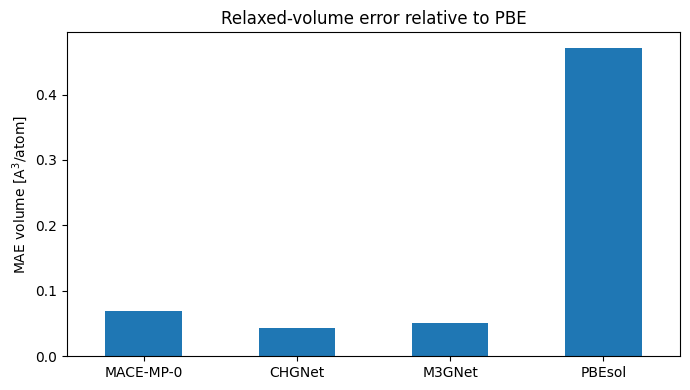

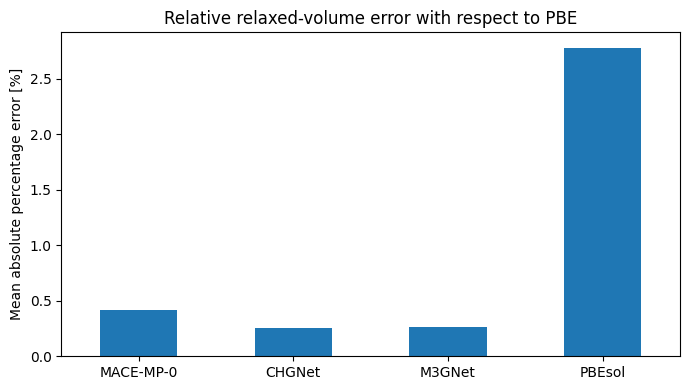

In [8]:
ax = volume_mae["MAE [A^3/atom]"].plot(
    kind="bar",
    figsize=(7, 4),
)

ax.set_ylabel("MAE volume [A$^3$/atom]")
ax.set_xlabel("")
ax.set_title("Relaxed-volume error relative to PBE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / "volume_mae.png", dpi=180, bbox_inches="tight")
plt.show()

ax = volume_mae["MAPE [%]"].plot(
    kind="bar",
    figsize=(7, 4),
)

ax.set_ylabel("Mean absolute percentage error [%]")
ax.set_xlabel("")
ax.set_title("Relative relaxed-volume error with respect to PBE")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURES / "volume_mape.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

## 5. Maximum phonon frequency - main benchmark metric

The maximum phonon frequency probes the stiffness of the potential around equilibrium.
Following Loew *et al.*, $\omega_{\max}$ is evaluated only at q-points
**commensurate with the supercell matrix**, not on the interpolated 20×20×20 mesh used
for thermodynamic properties.

The paper reports this error in Kelvin. Here 1 THz corresponds to approximately
47.99 K through $h\nu/k_B$.

In [9]:
omega_rows = []

for material in MATERIALS:
    ref = pbe[material]["omega_max_THz"]

    row = {
        "material": material,
        "PBE [THz]": ref,
        "PBEsol [THz]": pbesol[material]["omega_max_THz"],
    }

    for model in MODELS:
        label = MODEL_LABELS[model]
        pred = results[model][material]["omega_max_THz"]
        err = pred - ref

        row[f"{label} [THz]"] = pred
        row[f"{label} error [THz]"] = err
        row[f"{label} abs. error [K]"] = abs(err) * THZ_TO_K

    omega_rows.append(row)

omega_table = pd.DataFrame(omega_rows).set_index("material")

display(
    omega_table[
        [
            "PBE [THz]",
            "PBEsol [THz]",
            "MACE-MP-0 [THz]",
            "CHGNet [THz]",
            "M3GNet [THz]",
        ]
    ].round(3)
)

,PBE [THz],PBEsol [THz],MACE-MP-0 [THz],CHGNet [THz],M3GNet [THz]
material,,,,,
Si,15.107,15.287,11.190,13.104,8.469
SiC,24.418,24.729,21.876,17.967,19.925
AlP,12.792,13.020,10.509,9.363,8.966
ZnS,9.634,10.076,8.620,6.539,8.184
MgO,16.459,16.694,15.023,15.951,16.113
NaCl,6.254,6.499,5.515,4.196,5.549
AlN,25.039,25.409,19.986,22.536,22.706
GaN,20.412,21.022,18.616,19.103,18.322


In [10]:
omega_stats_rows = []

for model in MODELS:
    label = MODEL_LABELS[model]
    err_thz = omega_table[f"{label} error [THz]"].to_numpy()

    omega_stats_rows.append(
        {
            "model": label,
            "MAE [THz]": np.mean(np.abs(err_thz)),
            "MAE [K]": np.mean(np.abs(err_thz)) * THZ_TO_K,
            "mean signed error [THz]": np.mean(err_thz),
            "mean signed error [K]": np.mean(err_thz) * THZ_TO_K,
            "RMSE [K]": np.sqrt(np.mean(err_thz**2)) * THZ_TO_K,
        }
    )

omega_stats = pd.DataFrame(omega_stats_rows).set_index("model")
display(omega_stats.round(2))

,MAE [THz],MAE [K],mean signed error [THz],mean signed error [K],RMSE [K]
model,,,,,
MACE-MP-0,2.35,112.66,-2.35,-112.66,130.79
CHGNet,2.67,128.11,-2.67,-128.11,151.23
M3GNet,2.74,131.27,-2.74,-131.27,162.24


**Interpretation.** All three MLIPs underestimate $\omega_{\max}$ for every material in the subset, indicating a systematic softening relative to PBE. MACE-MP-0 gives the lowest MAE and RMSE, and is therefore the best-performing model of the three for this metric on the present subset. The RMSE is larger than the MAE for all models, indicating that a few materials contribute disproportionately large errors.

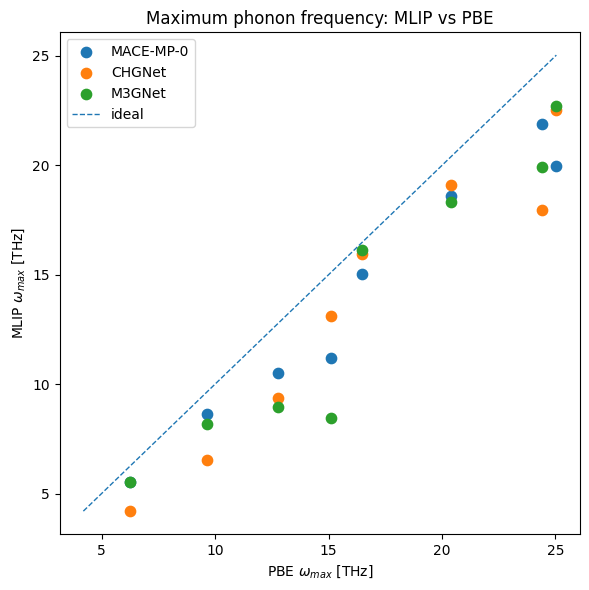

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))

pbe_omega = np.array(
    [pbe[m]["omega_max_THz"] for m in MATERIALS],
    dtype=float,
)

all_pred = []

for model in MODELS:
    pred = np.array(
        [results[model][m]["omega_max_THz"] for m in MATERIALS],
        dtype=float,
    )
    all_pred.extend(pred.tolist())

    ax.scatter(
        pbe_omega,
        pred,
        label=MODEL_LABELS[model],
        s=55,
    )

lo = min(pbe_omega.min(), min(all_pred))
hi = max(pbe_omega.max(), max(all_pred))

ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1, label="ideal")
ax.set_xlabel("PBE $\\omega_{max}$ [THz]")
ax.set_ylabel("MLIP $\\omega_{max}$ [THz]")
ax.set_title("Maximum phonon frequency: MLIP vs PBE")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / "omega_max_pred_vs_pbe.png", dpi=180, bbox_inches="tight")
plt.show()

### Interpretation

This plot compares the maximum phonon frequency predicted by each MLIP with the PBE reference.

The dashed diagonal represents the ideal case in which the MLIP prediction exactly matches PBE. Points below the diagonal indicate an underestimation of $\omega_{\max}$, corresponding to phonon softening, while points above the diagonal would indicate hardening.

All predictions in this subset lie below the ideal line, showing a systematic tendency of MACE-MP-0, CHGNet, and M3GNet to underestimate the maximum phonon frequency relative to PBE. Among the three models, MACE-MP-0 is overall the closest to the ideal diagonal, consistently with its lower aggregate error on this subset.

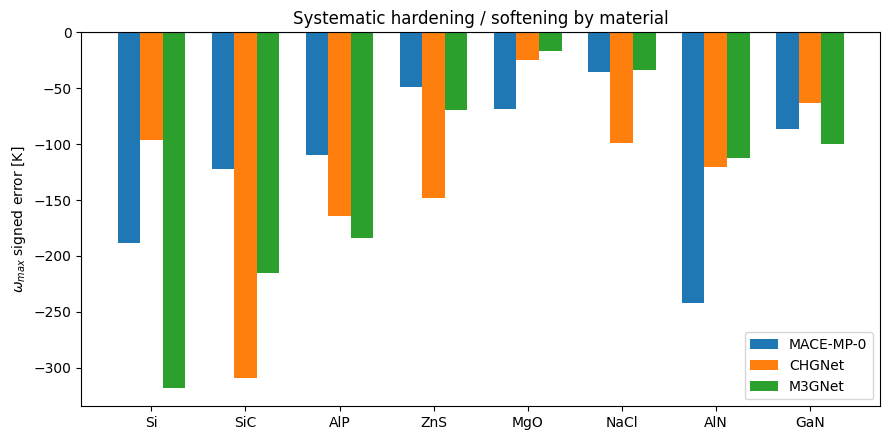

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.arange(len(MATERIALS))
width = 0.24

for i, model in enumerate(MODELS):
    label = MODEL_LABELS[model]
    errors_k = (
        omega_table[f"{label} error [THz]"].to_numpy()
        * THZ_TO_K
    )

    ax.bar(
        x + (i - 1) * width,
        errors_k,
        width=width,
        label=label,
    )

ax.axhline(0, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(MATERIALS)
ax.set_ylabel("$\\omega_{max}$ signed error [K]")
ax.set_title("Systematic hardening / softening by material")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / "omega_max_signed_errors.png", dpi=180, bbox_inches="tight")
plt.show()

### Interpretation

This plot shows the signed error in maximum phonon frequency for each material:

$$
\Delta \omega_{\max}
=
\omega_{\max}^{\mathrm{MLIP}}
-
\omega_{\max}^{\mathrm{PBE}}.
$$

A value of zero would indicate perfect agreement with PBE. Negative values correspond to phonon softening, while positive values would indicate hardening.

All errors are negative for all three MLIPs and all eight materials, confirming a systematic softening relative to PBE. The magnitude of the error is strongly material dependent: for example, CHGNet shows a particularly large deviation for SiC, while M3GNet deviates strongly for Si. MACE-MP-0 is generally more accurate, although it still shows significant errors for materials such as AlN and Si.

## 6. Comparison with the published full benchmark

The following values are **external reference values from Table 2 of Loew et al.**
They are not calculated from this repository.

| Model | MAE(omega_max) [K] | MAE(S) [J/K/mol] | MAE(F) [kJ/mol] | MAE(Cv) [J/K/mol] |
|---|---:|---:|---:|---:|
| MACE-MP-0 | 61 | 60 | 24 | 13 |
| CHGNet | 89 | 114 | 45 | 21 |
| M3GNet | 98 | 150 | 56 | 22 |
| PBEsol vs PBE | 33 | 25 | 10 | 5 |

These full-benchmark values provide **context**, not an expected numerical target for
an eight-material subset.

In [13]:
PAPER_MAE = pd.DataFrame(
    {
        "omega_max [K]": {
            "MACE-MP-0": 61.0,
            "CHGNet": 89.0,
            "M3GNet": 98.0,
            "PBEsol": 33.0,
        },
        "S [J/K/mol]": {
            "MACE-MP-0": 60.0,
            "CHGNet": 114.0,
            "M3GNet": 150.0,
            "PBEsol": 25.0,
        },
        "F [kJ/mol]": {
            "MACE-MP-0": 24.0,
            "CHGNet": 45.0,
            "M3GNet": 56.0,
            "PBEsol": 10.0,
        },
        "C_v [J/K/mol]": {
            "MACE-MP-0": 13.0,
            "CHGNet": 21.0,
            "M3GNet": 22.0,
            "PBEsol": 5.0,
        },
    }
)

omega_paper_comparison = pd.DataFrame(
    {
        "this 8-material subset [K]": omega_stats["MAE [K]"],
        "Loew et al. full benchmark [K]": PAPER_MAE.loc[
            ["MACE-MP-0", "CHGNet", "M3GNet"],
            "omega_max [K]",
        ],
    }
)

display(omega_paper_comparison.round(1))

,this 8-material subset [K],Loew et al. full benchmark [K]
MACE-MP-0,112.7,61.0
CHGNet,128.1,89.0
M3GNet,131.3,98.0


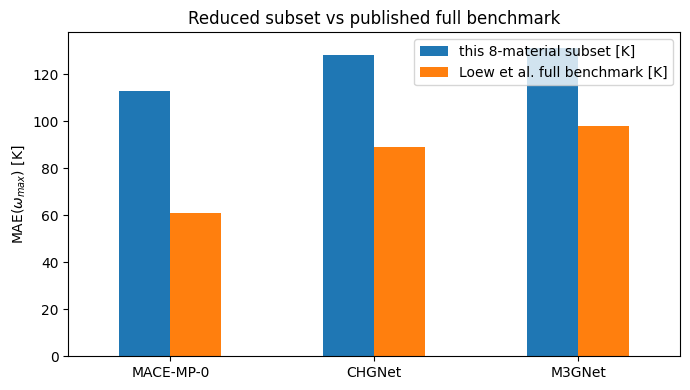

In [14]:
ax = omega_paper_comparison.plot(kind="bar", figsize=(7, 4))

ax.set_ylabel("MAE($\\omega_{max}$) [K]")
ax.set_xlabel("")
ax.set_title("Reduced subset vs published full benchmark")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / "omega_max_vs_paper.png", dpi=180, bbox_inches="tight")
plt.show()

In [15]:
our_ranking = list(omega_stats["MAE [K]"].sort_values().index)

paper_ranking = list(
    PAPER_MAE.loc[
        ["MACE-MP-0", "CHGNet", "M3GNet"],
        "omega_max [K]",
    ].sort_values().index
)

ranking_text = (
    "The ranking on this subset is **"
    + " < ".join(our_ranking)
    + "** (lower MAE is better). "
    + "The published full-benchmark ranking among these models is **"
    + " < ".join(paper_ranking)
    + "**."
)

if our_ranking == paper_ranking:
    ranking_text += (
        " The reduced subset reproduces the same ordering, although not "
        "necessarily the same MAE values."
    )
else:
    ranking_text += (
        " The ordering differs on this small subset, which is plausible because "
        "eight simple crystals are not statistically representative of the full dataset."
    )

display(Markdown(ranking_text))

The ranking on this subset is **MACE-MP-0 < CHGNet < M3GNet** (lower MAE is better). The published full-benchmark ranking among these models is **MACE-MP-0 < CHGNet < M3GNet**. The reduced subset reproduces the same ordering, although not necessarily the same MAE values.

## 7. Dynamical stability

A structure is classified as dynamically stable when no imaginary phonon frequencies
are present at the q-points commensurate with the supercell, except for the three
acoustic modes at Gamma where the benchmark allows a small negative tolerance down to
-50 K.

With only eight hand-picked crystals, this is primarily a consistency check rather than
a reproduction of the paper's confusion-matrix statistics.

In [16]:
stability_rows = []

for material in MATERIALS:
    row = {
        "material": material,
        "PBE stable": not pbe[material]["has_imaginary"],
        "PBEsol stable": not pbesol[material]["has_imaginary"],
    }

    for model in MODELS:
        row[f"{MODEL_LABELS[model]} stable"] = (
            not results[model][material]["has_imaginary"]
        )

    stability_rows.append(row)

stability_table = pd.DataFrame(stability_rows).set_index("material")
display(stability_table)

,PBE stable,PBEsol stable,MACE-MP-0 stable,CHGNet stable,M3GNet stable
material,,,,,
Si,True,True,True,True,True
SiC,True,True,True,True,True
AlP,True,True,True,True,True
ZnS,True,True,True,True,True
MgO,True,True,True,True,True
NaCl,True,True,True,True,True
AlN,True,True,True,True,True
GaN,True,True,True,True,True


In [17]:
stability_summary_rows = []

for model in MODELS:
    label = MODEL_LABELS[model]

    ref_stable = stability_table["PBE stable"].to_numpy(dtype=bool)
    pred_stable = stability_table[f"{label} stable"].to_numpy(dtype=bool)

    stability_summary_rows.append(
        {
            "model": label,
            "agreement": int(np.sum(ref_stable == pred_stable)),
            "out of": len(MATERIALS),
            "false unstable": int(np.sum(ref_stable & ~pred_stable)),
            "false stable": int(np.sum(~ref_stable & pred_stable)),
        }
    )

stability_summary = pd.DataFrame(stability_summary_rows).set_index("model")
display(stability_summary)

,agreement,out of,false unstable,false stable
model,,,,
MACE-MP-0,8,8,0,0
CHGNet,8,8,0,0
M3GNet,8,8,0,0


## 8. Phonon dispersions

The phonon dispersion relation describes how the phonon frequencies
$\omega_\nu(\mathbf{q})$ vary across reciprocal space. Each curve corresponds
to a different vibrational mode, or phonon branch, while $\mathbf{q}$ denotes
the phonon wave vector.

Rather than sampling the entire Brillouin zone, dispersion plots are usually
evaluated along a path connecting high-symmetry points such as
$\Gamma$, X, L, K, or W. The horizontal axis therefore represents a path in
reciprocal space, while the vertical axis gives the phonon frequency in THz.

Branches whose frequency approaches zero at $\Gamma$ are the acoustic modes.
The remaining branches are optical modes and generally retain a finite
frequency at $\Gamma$.

A scalar quantity such as $\omega_{\max}$ only measures the highest predicted
phonon frequency and cannot reveal where in reciprocal space the model differs
from DFT. Dispersion curves instead provide a branch-resolved comparison of
the complete vibrational spectrum along the selected path.

Three representative crystal structures are shown:

- **Si** - diamond;
- **SiC** - zincblende;
- **AlN** - wurtzite.

For each material, the high-symmetry path is generated from the PBE reference
and exactly the same q-points and path distances are used for PBE and all three
MLIPs. Therefore, differences between the curves originate from the predicted
phonon frequencies rather than from different reciprocal-space paths.

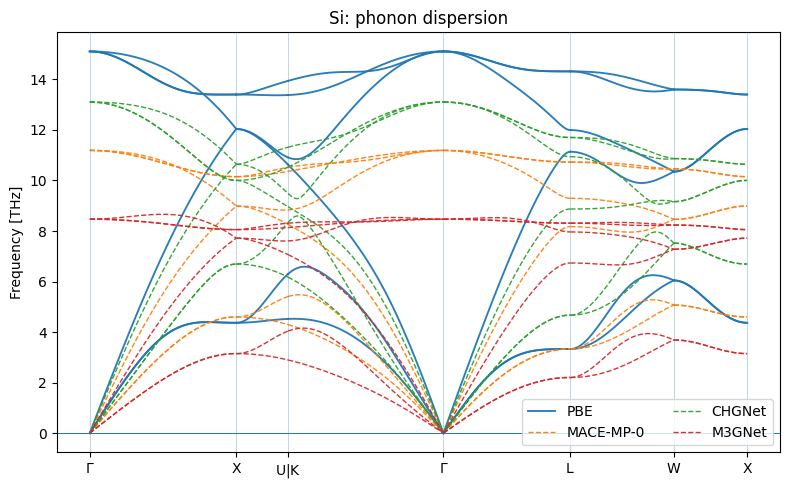

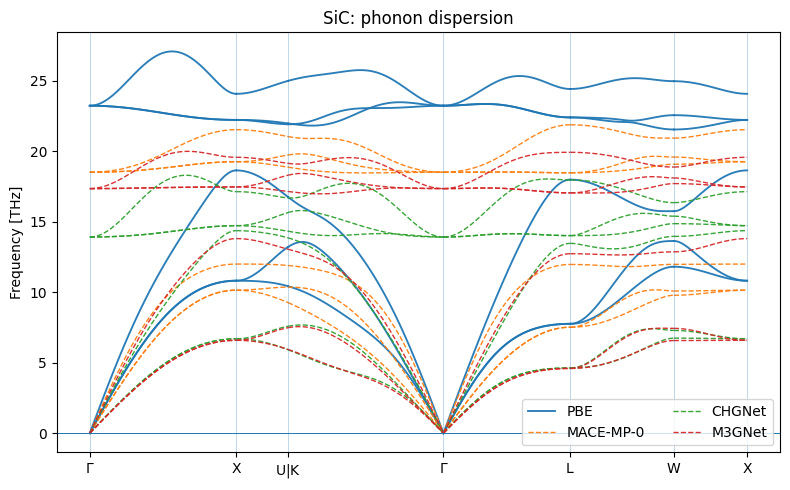

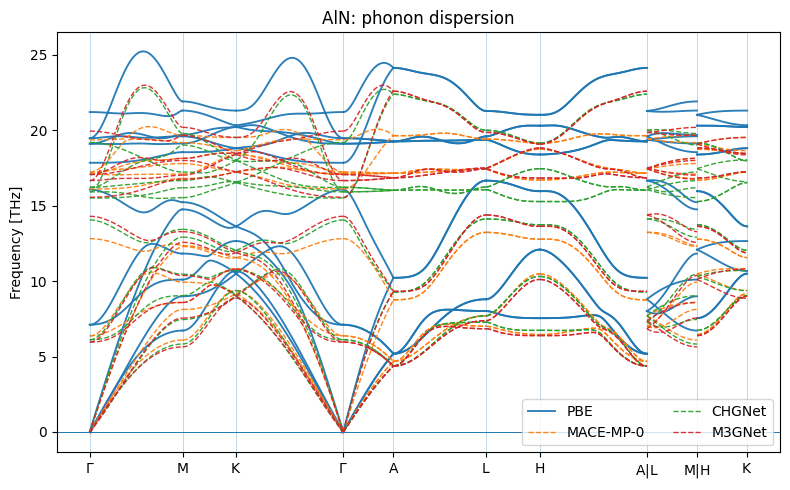

In [18]:
DISPERSION_MATERIALS = ["Si", "SiC", "AlN"]


def band_ticks(bands):
    distances = bands["distances"]
    labels = list(bands.get("labels") or [])
    connections = list(bands.get("path_connections") or [])

    if not labels:
        return [], []

    ticks = []
    tick_labels = []
    label_idx = 0

    def add_tick(x, label):
        if ticks and np.isclose(x, ticks[-1], atol=1e-10):
            if tick_labels[-1] != label:
                tick_labels[-1] += "|" + label
        else:
            ticks.append(x)
            tick_labels.append(label)

    for i, dist in enumerate(distances):
        dist = np.asarray(dist, dtype=float)

        # First segment, or first segment after a disconnected path.
        if i == 0 or not connections[i - 1]:
            add_tick(
                float(dist[0]),
                labels[label_idx],
            )
            label_idx += 1

        # End of current segment.
        add_tick(
            float(dist[-1]),
            labels[label_idx],
        )
        label_idx += 1

    assert label_idx == len(labels), (
        f"Used {label_idx} labels, but {len(labels)} were provided."
    )

    return ticks, tick_labels


def plot_dispersion(material):
    sources = [
        ("PBE", pbe[material]["bands"]),
        *[
            (MODEL_LABELS[model], results[model][material]["bands"])
            for model in MODELS
        ],
    ]

    default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(8, 5))

    for source_idx, (label, bands) in enumerate(sources):
        color = default_colors[source_idx % len(default_colors)]

        for seg_idx, (dist, freq) in enumerate(
            zip(bands["distances"], bands["frequencies"])
        ):
            dist = np.asarray(dist, dtype=float)
            freq = np.asarray(freq, dtype=float)

            for branch_idx in range(freq.shape[1]):
                ax.plot(
                    dist,
                    freq[:, branch_idx],
                    color=color,
                    linewidth=1.35 if label == "PBE" else 1.0,
                    linestyle="-" if label == "PBE" else "--",
                    alpha=0.95,
                    label=(
                        label
                        if seg_idx == 0 and branch_idx == 0
                        else None
                    ),
                )

    ticks, labels = band_ticks(pbe[material]["bands"])

    for x_tick in ticks:
        ax.axvline(x_tick, linewidth=0.5, alpha=0.4)

    ax.axhline(0, linewidth=0.7)
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Frequency [THz]")
    ax.set_title(f"{material}: phonon dispersion")
    ax.legend(ncol=2)

    plt.tight_layout()
    plt.savefig(
        FIGURES / f"dispersion_{material}.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()


for material in DISPERSION_MATERIALS:
    plot_dispersion(material)

### Interpretation

The MLIPs reproduce several qualitative features of the PBE phonon dispersions,
including the overall branch structure and the acoustic modes approaching zero
frequency at $\Gamma$. However, the agreement is not merely a matter of preserving
the curve shape: substantial quantitative differences are present in several branches.

In particular, the MLIP curves are generally shifted toward lower frequencies,
confirming the systematic phonon softening already observed from
$\omega_{\max}$. The dispersion plots show that this error is branch- and
q-point-dependent rather than a simple uniform shift of the entire spectrum.

## 9. Thermodynamic properties at 300 K

The phonon spectrum also determines several vibrational thermodynamic properties.
Here, the comparison is performed at **300 K** using a Gamma-centered
$20\times20\times20$ q-point mesh over the Brillouin zone.

The quantities considered are:

- **Vibrational entropy $S$** [J/K/mol], which measures the number of thermally
  accessible vibrational states. Softer phonon spectra generally lead to larger entropy.

- **Vibrational Helmholtz free energy $F$** [kJ/mol], which includes the energetic
  and entropic contribution of lattice vibrations. Since $F = U - TS$, an increase
  in vibrational entropy tends to lower the free energy.

- **Constant-volume heat capacity $C_V$** [J/K/mol], which measures how much thermal
  energy is absorbed by the vibrational degrees of freedom as the temperature increases.

These properties are obtained from the full phonon spectrum, rather than from a single
quantity such as $\omega_{\max}$. Therefore, they provide a complementary test of how
well each MLIP reproduces the vibrational behavior of the PBE reference.

The comparison is performed material by material. The absolute values should not be
compared directly across different materials, because the thermodynamic quantities are
not normalized by the number of atoms in the primitive cell in the benchmark protocol.

Because the MLIPs generally predict softer phonon spectra than PBE, one expects a
systematic tendency toward larger $S$ and $C_V$, and lower $F$. The following table
shows whether this trend is present in the eight-material subset.

In [19]:
THERMAL_METRICS = {
    "S": ("S [J/K/mol]", "J/K/mol"),
    "F": ("F [kJ/mol]", "kJ/mol"),
    "C_v": ("C_v [J/K/mol]", "J/K/mol"),
}

thermal_rows = []

for material in MATERIALS:
    row = {"material": material}

    for metric, (pretty, _) in THERMAL_METRICS.items():
        row[f"PBE {pretty}"] = pbe[material]["thermal_300K"][metric]
        row[f"PBEsol {pretty}"] = pbesol[material]["thermal_300K"][metric]

        for model in MODELS:
            row[f"{MODEL_LABELS[model]} {pretty}"] = (
                results[model][material]["thermal_300K"][metric]
            )

    thermal_rows.append(row)

thermal_table = pd.DataFrame(thermal_rows).set_index("material")
display(thermal_table.round(3))

,PBE S [J/K/mol],PBEsol S [J/K/mol],MACE-MP-0 S [J/K/mol],CHGNet S [J/K/mol],M3GNet S [J/K/mol],PBE F [kJ/mol],PBEsol F [kJ/mol],MACE-MP-0 F [kJ/mol],CHGNet F [kJ/mol],M3GNet F [kJ/mol],PBE C_v [J/K/mol],PBEsol C_v [J/K/mol],MACE-MP-0 C_v [J/K/mol],CHGNet C_v [J/K/mol],M3GNet C_v [J/K/mol]
material,,,,,,,,,,,,,,,
Si,39.332,39.692,48.437,40.758,60.237,6.519,6.488,2.505,5.366,-1.777,40.065,39.894,43.501,41.894,45.673
SiC,17.378,17.248,23.095,31.866,29.856,19.073,19.325,14.681,9.971,11.672,27.590,27.294,32.517,37.050,34.758
AlP,42.603,42.823,53.056,58.666,61.745,4.991,5.003,0.887,-1.104,-2.101,41.478,41.289,44.177,45.087,45.303
ZnS,60.469,58.829,64.944,75.704,71.800,-1.741,-1.102,-3.378,-7.025,-5.660,45.381,44.954,46.260,47.553,46.954
MgO,29.391,28.218,33.212,35.145,30.767,10.274,10.843,8.375,7.625,9.567,37.911,37.351,39.836,40.340,38.643
NaCl,74.994,72.701,76.247,99.910,79.927,-6.971,-6.218,-7.378,-14.787,-8.541,48.049,47.842,48.148,49.157,48.337
AlN,42.355,41.869,50.971,51.694,51.162,32.031,32.608,26.445,25.951,26.762,61.881,61.128,68.028,68.653,67.385
GaN,68.053,66.220,71.969,80.100,75.843,19.720,20.888,17.646,13.750,15.920,72.446,71.183,74.377,77.734,75.691


In [20]:
thermal_mae_rows = []

for model in MODELS:
    label = MODEL_LABELS[model]
    row = {"model": label}

    for metric, (_, unit) in THERMAL_METRICS.items():
        errors = np.array(
            [
                results[model][material]["thermal_300K"][metric]
                - pbe[material]["thermal_300K"][metric]
                for material in MATERIALS
            ],
            dtype=float,
        )

        row[f"MAE {metric} [{unit}]"] = np.mean(np.abs(errors))
        row[f"ME {metric} [{unit}]"] = np.mean(errors)

    thermal_mae_rows.append(row)

pbesol_row = {"model": "PBEsol"}

for metric, (_, unit) in THERMAL_METRICS.items():
    errors = np.array(
        [
            pbesol[material]["thermal_300K"][metric]
            - pbe[material]["thermal_300K"][metric]
            for material in MATERIALS
        ],
        dtype=float,
    )

    pbesol_row[f"MAE {metric} [{unit}]"] = np.mean(np.abs(errors))
    pbesol_row[f"ME {metric} [{unit}]"] = np.mean(errors)

thermal_mae_rows.append(pbesol_row)

thermal_mae = pd.DataFrame(thermal_mae_rows).set_index("model")
display(thermal_mae.round(2))

,MAE S [J/K/mol],ME S [J/K/mol],MAE F [kJ/mol],ME F [kJ/mol],MAE C_v [J/K/mol],ME C_v [J/K/mol]
model,,,,,,
MACE-MP-0,5.92,5.92,3.01,-3.01,2.76,2.76
CHGNet,12.41,12.41,5.52,-5.52,4.08,4.08
M3GNet,10.85,10.85,4.76,-4.76,3.49,3.49
PBEsol,1.02,-0.87,0.50,0.49,0.48,-0.48


In [21]:
paper_thermal_comparison = pd.DataFrame(
    {
        "subset S": thermal_mae.loc[
            ["MACE-MP-0", "CHGNet", "M3GNet"],
            "MAE S [J/K/mol]",
        ],
        "paper S": PAPER_MAE.loc[
            ["MACE-MP-0", "CHGNet", "M3GNet"],
            "S [J/K/mol]",
        ],
        "subset F": thermal_mae.loc[
            ["MACE-MP-0", "CHGNet", "M3GNet"],
            "MAE F [kJ/mol]",
        ],
        "paper F": PAPER_MAE.loc[
            ["MACE-MP-0", "CHGNet", "M3GNet"],
            "F [kJ/mol]",
        ],
        "subset C_v": thermal_mae.loc[
            ["MACE-MP-0", "CHGNet", "M3GNet"],
            "MAE C_v [J/K/mol]",
        ],
        "paper C_v": PAPER_MAE.loc[
            ["MACE-MP-0", "CHGNet", "M3GNet"],
            "C_v [J/K/mol]",
        ],
    }
)

display(paper_thermal_comparison.round(1))

,subset S,paper S,subset F,paper F,subset C_v,paper C_v
MACE-MP-0,5.9,60.0,3.0,24.0,2.8,13.0
CHGNet,12.4,114.0,5.5,45.0,4.1,21.0
M3GNet,10.8,150.0,4.8,56.0,3.5,22.0


**Interpretation note.** Unlike the volume, the thermodynamic quantities
$S$, $F$, and $C_V$ are not normalized by the number of atoms, consistently
with the post-processing procedure of Loew et al. Their absolute values and
errors therefore also depend on the number of atoms in the primitive cell.

Since the present subset contains only simple crystals with relatively small
primitive cells, this contributes to the substantially smaller thermodynamic
MAEs observed here compared with the full benchmark. The comparison with
Table 2 should therefore be interpreted mainly in terms of model ranking and
systematic trends, rather than as a direct comparison of absolute MAE values.

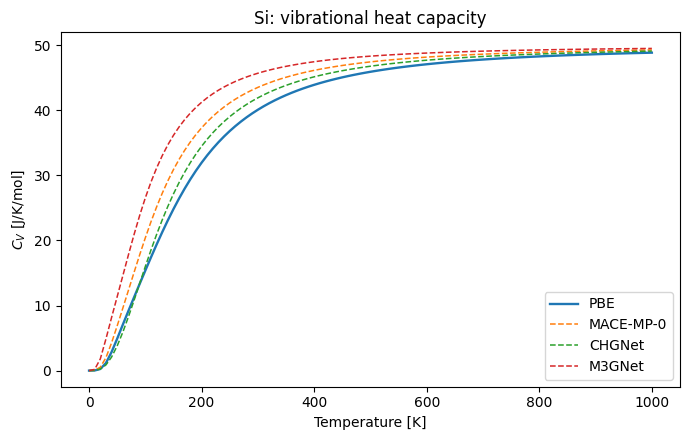

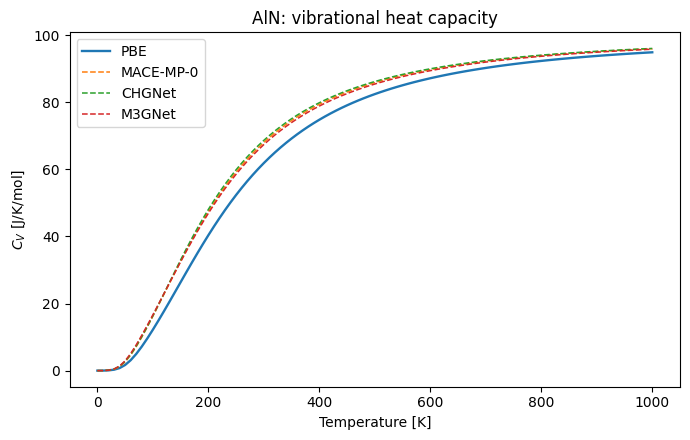

In [22]:
CURVE_MATERIALS = ["Si", "AlN"]

for material in CURVE_MATERIALS:
    fig, ax = plt.subplots(figsize=(7, 4.5))

    ax.plot(
        np.asarray(pbe[material]["thermal"]["T"], dtype=float),
        np.asarray(pbe[material]["thermal"]["C_v"], dtype=float),
        linewidth=1.7,
        label="PBE",
    )

    for model in MODELS:
        r = results[model][material]

        ax.plot(
            np.asarray(r["thermal"]["T"], dtype=float),
            np.asarray(r["thermal"]["C_v"], dtype=float),
            linestyle="--",
            linewidth=1.1,
            label=MODEL_LABELS[model],
        )

    ax.set_xlabel("Temperature [K]")
    ax.set_ylabel("$C_V$ [J/K/mol]")
    ax.set_title(f"{material}: vibrational heat capacity")
    ax.legend()

    plt.tight_layout()
    plt.savefig(
        FIGURES / f"heat_capacity_{material}.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

### Interpretation

The heat-capacity curves provide a temperature-dependent view of the effect of
phonon softening.

At low temperature, $C_V$ approaches zero because only very few vibrational
modes are thermally excited. As the temperature increases, progressively more
phonon modes become populated and the heat capacity rises.

The MLIPs generally predict larger $C_V$ than PBE at intermediate temperatures.
This is consistent with their softer phonon spectra: lower-frequency modes can
be thermally excited at lower temperatures.

At high temperature, all curves approach the classical Dulong–Petit limit

$$
C_V \rightarrow 3 N R,
$$

where $N$ is the number of atoms in the primitive cell. This also explains why
the asymptotic values differ between materials: Si approaches about
50 J/K/mol, while AlN approaches about 100 J/K/mol because their primitive cells
contain different numbers of atoms.

For Si, M3GNet shows the strongest deviation from PBE at intermediate
temperatures, consistent with the large phonon softening observed in its
dispersion. For AlN, the three MLIPs behave more similarly, although they still
predict a slightly larger heat capacity than PBE over much of the temperature
range.

## 10. PBEsol as a DFT-level baseline

The PBE–PBEsol difference gives a physically meaningful reference scale: it shows how
much the observables change even when both calculations are first-principles DFT but use
different exchange-correlation functionals.

The full paper reports that PBEsol generally contracts cells and hardens phonons
relative to PBE. The following table checks the same tendency on this reduced subset.

In [23]:
pbesol_rows = []

for material in MATERIALS:
    delta_omega_thz = (
        pbesol[material]["omega_max_THz"]
        - pbe[material]["omega_max_THz"]
    )

    pbesol_rows.append(
        {
            "material": material,
            "delta volume [A^3/atom]": (
                pbesol[material]["volume"] / pbesol[material]["n_atoms_unitcell"]
                - pbe[material]["volume"] / pbe[material]["n_atoms_unitcell"]
            ),
            "delta omega_max [THz]": delta_omega_thz,
            "delta omega_max [K]": delta_omega_thz * THZ_TO_K,
            "delta S [J/K/mol]": (
                pbesol[material]["thermal_300K"]["S"]
                - pbe[material]["thermal_300K"]["S"]
            ),
            "delta F [kJ/mol]": (
                pbesol[material]["thermal_300K"]["F"]
                - pbe[material]["thermal_300K"]["F"]
            ),
            "delta C_v [J/K/mol]": (
                pbesol[material]["thermal_300K"]["C_v"]
                - pbe[material]["thermal_300K"]["C_v"]
            ),
        }
    )

pbesol_table = pd.DataFrame(pbesol_rows).set_index("material")
display(pbesol_table.round(3))

,delta volume [A^3/atom],delta omega_max [THz],delta omega_max [K],delta S [J/K/mol],delta F [kJ/mol],delta C_v [J/K/mol]
material,,,,,,
Si,-0.364,0.180,8.626,0.360,-0.031,-0.172
SiC,-0.145,0.311,14.927,-0.130,0.251,-0.296
AlP,-0.388,0.228,10.935,0.219,0.012,-0.189
ZnS,-0.946,0.443,21.248,-1.640,0.639,-0.427
MgO,-0.260,0.235,11.273,-1.173,0.569,-0.559
NaCl,-1.087,0.244,11.720,-2.293,0.753,-0.207
AlN,-0.170,0.369,17.719,-0.486,0.577,-0.753
GaN,-0.410,0.610,29.285,-1.833,1.168,-1.263


In [24]:
pbesol_benchmark_comparison = pd.DataFrame(
    {
        "subset PBEsol vs PBE": [
            np.mean(np.abs(pbesol_table["delta omega_max [K]"])),
            thermal_mae.loc["PBEsol", "MAE S [J/K/mol]"],
            thermal_mae.loc["PBEsol", "MAE F [kJ/mol]"],
            thermal_mae.loc["PBEsol", "MAE C_v [J/K/mol]"],
        ],
        "Loew et al. full benchmark": [
            PAPER_MAE.loc["PBEsol", "omega_max [K]"],
            PAPER_MAE.loc["PBEsol", "S [J/K/mol]"],
            PAPER_MAE.loc["PBEsol", "F [kJ/mol]"],
            PAPER_MAE.loc["PBEsol", "C_v [J/K/mol]"],
        ],
    },
    index=[
        "omega_max [K]",
        "S [J/K/mol]",
        "F [kJ/mol]",
        "C_v [J/K/mol]",
    ],
)

display(pbesol_benchmark_comparison.round(2))

,subset PBEsol vs PBE,Loew et al. full benchmark
omega_max [K],15.72,33.0
S [J/K/mol],1.02,25.0
F [kJ/mol],0.50,10.0
C_v [J/K/mol],0.48,5.0


## 11. Runtime - descriptive only

The JSON files contain end-to-end runtime for each material. These values are useful as
implementation metadata but **not** as a controlled speed benchmark, because the three
models use different software stacks and potentially different execution backends.

In [25]:
runtime_table = pd.DataFrame(
    [
        {
            "model": MODEL_LABELS[model],
            "mean runtime [s]": np.mean(
                [results[model][m]["runtime_s"] for m in MATERIALS]
            ),
            "median runtime [s]": np.median(
                [results[model][m]["runtime_s"] for m in MATERIALS]
            ),
            "total runtime [s]": np.sum(
                [results[model][m]["runtime_s"] for m in MATERIALS]
            ),
        }
        for model in MODELS
    ]
).set_index("model")

display(runtime_table.round(2))

,mean runtime [s],median runtime [s],total runtime [s]
model,,,
MACE-MP-0,4.18,3.60,33.41
CHGNet,2.11,1.56,16.90
M3GNet,2.36,1.60,18.85


In [26]:
from ase.io import write

ph = pbe["SiC"]["ph"]

q = [0.0, 0.0, 0.0]

q_result = ph.run_qpoints(
    [q],
    with_eigenvectors=True,
)

freqs = np.asarray(q_result.frequencies[0])
eigvecs = np.asarray(q_result.eigenvectors[0])

mode_index = int(np.argmax(freqs))
frequency = freqs[mode_index]

primitive = ph_to_ase(ph.primitive)
masses = np.asarray(ph.primitive.masses)

mode = eigvecs[:, mode_index].reshape(len(masses), 3)

mode = mode / np.sqrt(masses)[:, None]

if np.max(np.abs(mode.real)) >= np.max(np.abs(mode.imag)):
    displacement = mode.real
else:
    displacement = mode.imag

displacement /= np.max(
    np.linalg.norm(displacement, axis=1)
)

repetitions = (4, 4, 4)
atoms = primitive.repeat(repetitions)

displacement_supercell = np.tile(
    displacement,
    (np.prod(repetitions), 1),
)

amplitude = 0.25

frames = []

for phase in np.linspace(0, 2 * np.pi, 40, endpoint=False):
    frame = atoms.copy()

    frame.positions += (
        amplitude
        * np.sin(phase)
        * displacement_supercell
    )

    frames.append(frame)

output = FIGURES / "SiC_PBE_Gamma_optical.xyz"

write(
    output,
    frames,
    format="xyz",
)

print("Gamma frequencies [THz]:", np.round(freqs, 3))
print(
    f"Animated mode: band {mode_index + 1}, "
    f"frequency = {frequency:.3f} THz"
)
print("Written to:", output)

Gamma frequencies [THz]: [-0.   -0.   -0.   23.23 23.23 23.23]
Animated mode: band 5, frequency = 23.230 THz
Written to: C:\Users\antoj\Desktop\Tonio\projects\mlip-phonon-benchmark\figures\SiC_PBE_Gamma_optical.xyz


## 12. Data-driven discussion

The following cell builds a compact interpretation directly from the current JSON files.
This prevents the written discussion from silently becoming inconsistent with regenerated
results.

In [27]:
best_omega = omega_stats["MAE [K]"].idxmin()

bias_lines = []

for model in MODELS:
    label = MODEL_LABELS[model]
    bias = omega_stats.loc[label, "mean signed error [K]"]

    if abs(bias) < 1.0:
        tendency = "shows essentially no mean signed bias"
    elif bias < 0:
        tendency = "shows a mean softening"
    else:
        tendency = "shows a mean hardening"

    bias_lines.append(
        f"- **{label}** {tendency} of {bias:+.1f} K in omega_max."
    )

our_rank = " < ".join(
    omega_stats["MAE [K]"].sort_values().index
)

paper_rank = " < ".join(
    PAPER_MAE.loc[
        ["MACE-MP-0", "CHGNet", "M3GNet"],
        "omega_max [K]",
    ].sort_values().index
)

stability_lines = []

for model in MODELS:
    label = MODEL_LABELS[model]
    agreement = int(stability_summary.loc[label, "agreement"])

    stability_lines.append(
        f"- **{label}** agrees with PBE for "
        f"{agreement}/{len(MATERIALS)} stability classifications."
    )

discussion_lines = [
    "### Main observations from this eight-material subset",
    "",
    f"**Maximum frequency.** The lowest subset MAE is obtained by **{best_omega}**.",
    f"The subset ranking is **{our_rank}**, whereas the full-benchmark ranking "
    f"among these three models is **{paper_rank}**.",
    "",
    *bias_lines,
    "",
    "**Dynamical stability.**",
    "",
    *stability_lines,
    "",
    "These numbers should be interpreted as a **small case study**, not as an "
    "independent statistical reproduction of the approximately 10,000-material "
    "benchmark. Agreement in ranking or systematic bias is meaningful qualitative "
    "evidence; disagreement for one or two materials can reflect the deliberately "
    "narrow composition and crystal-structure distribution used here.",
]

display(Markdown("\n".join(discussion_lines)))

### Main observations from this eight-material subset

**Maximum frequency.** The lowest subset MAE is obtained by **MACE-MP-0**.
The subset ranking is **MACE-MP-0 < CHGNet < M3GNet**, whereas the full-benchmark ranking among these three models is **MACE-MP-0 < CHGNet < M3GNet**.

- **MACE-MP-0** shows a mean softening of -112.7 K in omega_max.
- **CHGNet** shows a mean softening of -128.1 K in omega_max.
- **M3GNet** shows a mean softening of -131.3 K in omega_max.

**Dynamical stability.**

- **MACE-MP-0** agrees with PBE for 8/8 stability classifications.
- **CHGNet** agrees with PBE for 8/8 stability classifications.
- **M3GNet** agrees with PBE for 8/8 stability classifications.

These numbers should be interpreted as a **small case study**, not as an independent statistical reproduction of the approximately 10,000-material benchmark. Agreement in ranking or systematic bias is meaningful qualitative evidence; disagreement for one or two materials can reflect the deliberately narrow composition and crystal-structure distribution used here.

## 13. Conclusions and limitations

This project investigated whether three pretrained universal machine-learning
interatomic potentials — MACE-MP-0, CHGNet, and M3GNet — can reproduce harmonic
vibrational properties obtained from PBE DFT, even though these properties depend on
the **curvature of the potential-energy surface**, i.e. on second derivatives of the
energy rather than only on the energies, forces, and stresses used during training.

The methodology was kept aligned with Loew *et al.* wherever possible:

- PBE Alexandria structures were used as initial geometries and as the main DFT reference;
- all MLIP structures were relaxed while preserving crystal symmetry;
- the PBE supercell and primitive matrices were reused;
- harmonic force constants were obtained from finite displacements of 0.01 Å;
- residual force drift was removed and the force constants were symmetrized;
- $\omega_{\max}$ and dynamical stability were evaluated at q-points commensurate
  with the supercell;
- thermodynamic properties were evaluated on a $20\times20\times20$ q-point mesh;
- dispersion curves were evaluated along the same PBE-derived high-symmetry paths;
- non-analytical corrections (NAC) were disabled consistently for both DFT and MLIP
  comparisons.

### Main results

All three MLIPs reproduce the general qualitative structure of the PBE phonon
dispersions, but systematically predict softer phonon spectra.

For $\omega_{\max}$, every MLIP prediction in the eight-material subset lies below
the corresponding PBE value. The resulting MAEs are approximately:

- **MACE-MP-0:** 113 K;
- **CHGNet:** 128 K;
- **M3GNet:** 131 K.

MACE-MP-0 therefore gives the lowest MAE and RMSE for $\omega_{\max}$ on this subset.
Importantly, the model ranking

$$
\mathrm{MACE} < \mathrm{CHGNet} < \mathrm{M3GNet}
$$

is the same as that reported by Loew *et al.* on the full benchmark, although the
absolute errors differ because the present subset is much smaller and is not
statistically representative.

The systematic phonon softening is also reflected in the thermodynamic properties.
The three MLIPs generally predict larger vibrational entropy and heat capacity and
lower Helmholtz free energy than PBE. MACE-MP-0 gives the lowest MAE for all three
thermodynamic quantities on this subset.

All eight PBE reference structures are dynamically stable, and all three MLIPs
correctly reproduce this classification, with no spurious instability introduced in
the selected materials.

The relaxed volumes are generally very close to PBE. Interestingly, CHGNet gives the
lowest average volume error, while MACE performs better for the phonon and
thermodynamic metrics. This illustrates that accurately reproducing the position of
the energy minimum does not necessarily imply equally accurate prediction of the
curvature of the potential-energy surface around that minimum.

PBEsol systematically predicts smaller equilibrium volumes and generally harder
phonons than PBE, providing a useful DFT-level reference for the scale of the MLIP
errors.

### Limitations

The main limitation is the dataset size. The eight selected materials form a small
set of simple crystals spanning diamond, zincblende, rocksalt, and wurtzite
structures, but they are neither a random nor a statistically representative sample
of the approximately 10,000 compounds considered in the published benchmark.
Aggregate MAEs from this study should therefore be interpreted as case-study
statistics rather than estimates of general MLIP performance.

The selected materials are also all dynamically stable, so this subset cannot provide
a meaningful assessment of the ability of the models to distinguish stable from
unstable structures.

The study is restricted to the harmonic approximation and does not investigate
anharmonic phonon effects. In addition, the phonon DOS and average sound-velocity
metrics reported by Loew *et al.* were not reproduced.

For polar materials, NAC was intentionally disabled because the considered MLIPs do
not provide Born effective charges and dielectric tensors. Consequently, effects such
as LO-TO splitting are not included in the comparison.

Finally, the recorded runtimes should be considered descriptive only: the three
models use different software stacks, numerical precisions, and computational
backends, so they do not constitute a controlled performance benchmark.

Overall, the reduced benchmark reproduces the main qualitative conclusion of the
published study: pretrained universal MLIPs can capture substantial information about
harmonic vibrational properties without being explicitly trained on phonons, with
MACE-MP-0 showing the best overall phonon performance among the three models tested
here. Nevertheless, systematic softening and significant material-dependent errors
remain visible.

## 14. References

1. A. Loew, D. Sun, H.-C. Wang, S. Botti, M. A. L. Marques,  
   **Universal machine learning interatomic potentials are ready for phonons**,  
   *npj Computational Materials* **11**, 178 (2025).  
   DOI: https://doi.org/10.1038/s41524-025-01650-1

2. A. Togo, I. Tanaka,  
   **First principles phonon calculations in materials science**,  
   *Scripta Materialia* **108**, 1–5 (2015).  
   https://phonopy.github.io/phonopy/

3. I. Batatia *et al.*,  
   **MACE: Higher Order Equivariant Message Passing Neural Networks for Fast and Accurate Force Fields**,  
   NeurIPS (2022).

4. B. Deng *et al.*,  
   **CHGNet as a pretrained universal neural network potential for charge-informed atomistic modelling**,  
   *Nature Machine Intelligence* **5**, 1031–1041 (2023).

5. C. Chen, S. P. Ong,  
   **A universal graph deep learning interatomic potential for the periodic table**,  
   *Nature Computational Science* **2**, 718–728 (2022).

6. Alexandria phonon benchmark: https://alexandria.icams.rub.de/